# Customer Segmentation Analysis using RFM and K-Means Clustering

## Author
Saloni Kaushal

## Objective
The goal of this project is to segment retail customers into different groups based on their purchasing behavior using RFM Analysis and K-Means Clustering.

## Tools Used
- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Scikit-Learn

# Import Required Libraries

In this step, we import all the libraries required for data manipulation, visualization, and machine learning.

### Libraries Used:
- Pandas → Data handling
- NumPy → Numerical computations
- Matplotlib → Visualization
- Seaborn → Advanced visualization
- Scikit-Learn → K-Means clustering and feature scaling

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Load the Dataset

The dataset contains customer transaction details such as:

- Customer ID
- Invoice Number
- Purchase Date
- Quantity Purchased
- Unit Price

We load the dataset into a Pandas DataFrame.

In [2]:
df = pd.read_csv('OnlineRetail.csv', encoding='latin1')

df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


# Dataset Exploration

Before analysis, it is important to understand the dataset.

We will:
1. Check data types
2. Check missing values
3. Generate statistical summary

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  str    
 1   StockCode    541909 non-null  str    
 2   Description  540455 non-null  str    
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  str    
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  str    
dtypes: float64(2), int64(1), str(5)
memory usage: 33.1 MB


In [4]:
df.describe()

,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


In [5]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

# Data Cleaning

Real-world datasets often contain:

- Missing values
- Invalid entries
- Duplicate records

To improve analysis quality, we remove:

- Missing values
- Negative quantities
- Negative prices

In [7]:
df = df.dropna()

In [8]:
df = df[df['Quantity'] > 0]

In [9]:
df = df[df['UnitPrice'] > 0]

# Create Total Amount Column

Customer spending is calculated using:

Total Amount = Quantity × Unit Price

This feature will later be used in RFM Analysis.

In [10]:
df['TotalAmount'] = df['Quantity'] * df['UnitPrice']

df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalAmount
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom,20.34


# Convert Date Column

The InvoiceDate column must be converted into DateTime format so that Recency can be calculated accurately.

In [11]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

# RFM Analysis

RFM stands for:

### Recency (R)
How recently a customer made a purchase.

### Frequency (F)
How often a customer makes purchases.

### Monetary (M)
How much money a customer spends.

RFM helps businesses identify valuable customers.

# Create Snapshot Date

To calculate Recency, we use one day after the most recent transaction as the reference date.

In [13]:
snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

snapshot_date

Timestamp('2011-12-10 12:50:00')

# Calculate RFM Values

We group transactions by Customer ID and calculate:

- Recency
- Frequency
- Monetary Value

In [14]:
rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,
    'InvoiceNo': 'count',
    'TotalAmount': 'sum'
})

In [15]:
rfm.columns = ['Recency', 'Frequency', 'Monetary']

rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,326,1,77183.60
12347.0,2,182,4310.00
12348.0,75,31,1797.24
12349.0,19,73,1757.55
12350.0,310,17,334.40


# Feature Scaling

Machine Learning algorithms perform better when features are on a similar scale.

StandardScaler standardizes the data by converting values into z-scores.

In [16]:
scaler = StandardScaler()

rfm_scaled = scaler.fit_transform(rfm)

rfm_scaled

array([[ 2.33457414e+00, -3.96577702e-01,  8.35866818e+00],
       [-9.05340320e-01,  3.94648958e-01,  2.50966264e-01],
       [-1.75359593e-01, -2.65435162e-01, -2.85960063e-02],
       ...,
       [-8.45341904e-01, -3.48492104e-01, -2.08742313e-01],
       [-8.85340848e-01,  2.90384290e+00,  4.51854273e-03],
       [-4.95351144e-01, -9.49498596e-02, -2.41412739e-02]],
      shape=(4338, 3))

# K-Means Clustering

K-Means is an Unsupervised Machine Learning algorithm.

It groups similar customers together based on:

- Recency
- Frequency
- Monetary Value

In this project, we divide customers into 4 clusters.

# Apply K-Means Clustering

The algorithm will assign each customer to one of the four clusters.

In [18]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42
)

rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

# Cluster Distribution

Let's see how many customers belong to each cluster.

In [20]:
rfm['Cluster'].value_counts()

Cluster
0    2171
1    1326
3     828
2      13
Name: count, dtype: int64

# Cluster Summary

The average RFM values of each cluster help us understand customer behavior.

In [21]:
cluster_summary = rfm.groupby('Cluster').mean()

cluster_summary

,Recency,Frequency,Monetary
Cluster,,,
0,20.990788,135.285122,2645.818172
1,98.218703,37.719457,773.877083
2,4.692308,2565.307692,126118.310000
3,272.407005,25.138889,605.842525


# Visualize Customer Segments

Scatter Plot:

- X-axis → Frequency
- Y-axis → Monetary Value
- Color → Customer Cluster

This helps us visualize customer groups.

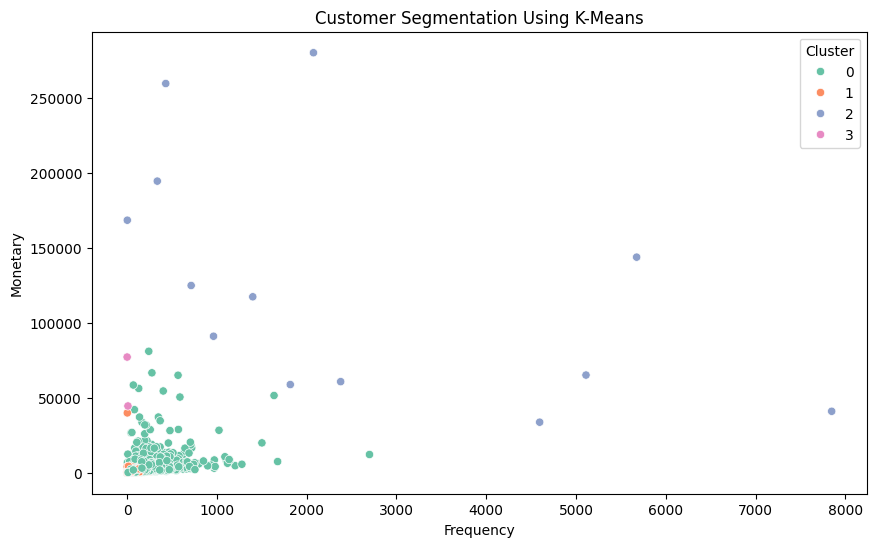

In [22]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    x='Frequency',
    y='Monetary',
    hue='Cluster',
    data=rfm,
    palette='Set2'
)

plt.title("Customer Segmentation Using K-Means")
plt.show()

# Save Cluster Plot

Save the generated visualization for project submission and GitHub repository.

In [23]:
plt.savefig('cluster_plot.png')

<Figure size 640x480 with 0 Axes>

# Interpretation of Customer Segments

### Cluster 0
High-value customers with frequent purchases.

### Cluster 1
Regular customers with moderate spending.

### Cluster 2
New or occasional customers.

### Cluster 3
Customers at risk of churn.

These insights help businesses create targeted marketing strategies.

# Conclusion

In this project:

1. Retail customer data was analyzed.

2. RFM metrics were calculated.

3. K-Means clustering was applied.

4. Customers were segmented into meaningful groups.

5. Results can be used for personalized marketing and customer retention strategies.